In [1]:
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import platform, os, shutil

# 캐시 초기화 (폰트 반영 안 될 때 대비)
cache_dir = mpl.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

system_name = platform.system()

if system_name == 'Windows':
    # Windows는 맑은 고딕이 기본 내장
    plt.rcParams['font.family'] = 'Malgun Gothic'

elif system_name == 'Darwin':
    # macOS는 애플고딕이 기본 내장
    plt.rcParams['font.family'] = 'AppleGothic'

else:
    # Linux / Colab 등: 나눔고딕 설치 필요
    os.system('apt-get -qq -y install fonts-nanum > /dev/null 2>&1')
    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rcParams['font.family'] = 'NanumGothic'
    else:
        print("⚠️ 나눔고딕 폰트를 찾을 수 없습니다. 한글이 깨질 수 있어요.")

plt.rcParams['axes.unicode_minus'] = False

In [3]:
# =============================================================
# marketing_campaign.csv 전처리 (Colab)
# 팀 결정사항(데이터_전처리.md) 반영
# =============================================================
import numpy as np
import pandas as pd

pd.set_option("display.width", 200)

df = pd.read_csv("../marketing_campaign.csv", sep=";", encoding="utf-8-sig")
print(f"[0] 원본 적재: {df.shape[0]}행 x {df.shape[1]}열")
n_before = len(df)

# 단위경제성 상수 (컬럼 삭제 전에 값 보관 — 손익분기 계산에 계속 필요)
COST_PER_CONTACT = int(df["Z_CostContact"].iloc[0])   # 3
REVENUE_PER_ACCEPT = int(df["Z_Revenue"].iloc[0])     # 11
BREAKEVEN_RATE = COST_PER_CONTACT / REVENUE_PER_ACCEPT
print(f"    손익분기 반응률 = {COST_PER_CONTACT}/{REVENUE_PER_ACCEPT} = {BREAKEVEN_RATE:.1%}")

# -------------------------------------------------------------
# 1. 완전중복 처리 (2단계)
#    ID를 제외한 28개 컬럼이 일치하는 레코드가 다수 존재.
#    Recency/Income/Dt_Customer가 동시에 일치할 확률은 사실상 0
#    -> 우연이 아니라 적재 과정의 중복 삽입.
# -------------------------------------------------------------

# 1a. Response까지 완전히 같은 행 -> 한 개만 남김 (관련 358행 / 제거 182건)
dup_key_all = [c for c in df.columns if c != "ID"]
n_full_dup_rows = int(df.duplicated(subset=dup_key_all, keep=False).sum())
df = df.drop_duplicates(subset=dup_key_all, keep="first").reset_index(drop=True)
print(f"[1a] 완전중복(Response 포함) 제거: 관련 {n_full_dup_rows}행 중 "
      f"{n_before - len(df)}건 삭제 -> {len(df)}행")

# 1b. Response만 다른 경우 -> Response=1 행을 대표값으로 남기고 나머지 삭제
#     (팀 결정: 삭제 대신 "캠페인에 반응한 적이 있다"는 신호를 보존)
n_before_1b = len(df)
conf_key = [c for c in df.columns if c not in ("ID", "Response")]
df["_conf_grp_size"] = df.groupby(conf_key, dropna=False)["Response"].transform("nunique")
conflict_mask = df["_conf_grp_size"] > 1

# 상충 그룹 내에서 Response=1 우선, 동일 그룹 내 첫 행만 유지
df["_sort_key"] = -df["Response"]  # Response=1이 위로 오도록 정렬
df = df.sort_values("_sort_key").drop_duplicates(subset=conf_key, keep="first")
df = df.drop(columns=["_conf_grp_size", "_sort_key"]).reset_index(drop=True)

print(f"[1b] Response만 상충하는 중복: Response=1 행을 대표값으로 채택 "
      f"-> {n_before_1b}행 -> {len(df)}행 (삭제 {n_before_1b - len(df)}건)")
print(f"[1]  중복 처리 합계: {n_before}행 -> {len(df)}행 "
      f"(삭제 {n_before - len(df)}건, {(n_before - len(df)) / n_before:.1%})")

# -------------------------------------------------------------
# 2. 불필요한 상수 컬럼 제거
# -------------------------------------------------------------
df = df.drop(columns=["Z_CostContact", "Z_Revenue"])
print("[2] Z_CostContact, Z_Revenue 컬럼 삭제 (값은 위 BREAKEVEN_RATE로 보존)")

# -------------------------------------------------------------
# 3. Income 결측/이상치 처리
#    - 극단값(666666) 포함 전체를 중앙값으로 대체 (팀 결정: 전체 기준 중앙값)
#    - Income=7500이 12건 반복되나, 생년/학력/혼인상태/가입일이 전부 달라
#      중복 삽입이 아닌 하한값(설문 기본값 등)으로 판단 -> 그대로 유지, 주석만 남김
# -------------------------------------------------------------
df["Income_missing"] = df["Income"].isna().astype(int)
n_income_missing = int(df["Income_missing"].sum())

income_median = df["Income"].median()
df["Income"] = df["Income"].fillna(income_median)

n_income_outlier = int((df["Income"] > 200000).sum())
df.loc[df["Income"] > 200000, "Income"] = income_median

print(f"[3] Income: 결측 {n_income_missing}건 + 이상치(>200000) {n_income_outlier}건 "
      f"-> 전체 중앙값({income_median:,.0f})으로 대체")
print("    * Income=7500이 12건 존재하나 다른 모든 컬럼값이 서로 다름 "
      "-> 중복 삽입이 아닌 소득 하한값(설문 기본응답 등)으로 추정, 그대로 유지")

# -------------------------------------------------------------
# 4. Year_Birth -> Age 파생 (2014년 기준), 극단적 이상치 필터링
#    1893/1899/1900년생 3건은 2014년 기준 114~121세로 비현실적 -> 행 제거
# -------------------------------------------------------------
n_before_age = len(df)
df = df[df["Year_Birth"] >= 1940].reset_index(drop=True)
print(f"[4] Year_Birth<1940 (3건, 114~121세) 제거: {n_before_age} -> {len(df)}행")

df["Age"] = 2014 - df["Year_Birth"]

# 나중에 범주형으로 묶기 위한 연령대 구간 (필요 시 EDA/모델링 단계에서 사용)
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 30, 40, 50, 60, 70, 200],
    labels=["20대이하", "30대", "40대", "50대", "60대", "70대이상"],
)
print("    Age 파생 완료(2014년 기준), AgeGroup 범주형 컬럼 생성")

# -------------------------------------------------------------
# 5. Education 4개 범주로 정리 (2n Cycle -> Master 편입)
# -------------------------------------------------------------
df["Education"] = df["Education"].replace({"2n Cycle": "Master"})
print("[5] Education: 2n Cycle -> Master 편입, 잔존 범주:",
      sorted(df["Education"].unique()))

# -------------------------------------------------------------
# 6. Marital_Status 정리
#    Alone, Absurd, YOLO -> Single 로 병합 (표본 3+2+2=7건, 정상 범주와 병합)
#    Married, Together, Single, Divorced, Widow 는 그대로 유지
# -------------------------------------------------------------
marital_map = {"Alone": "Single", "Absurd": "Single", "YOLO": "Single"}
n_recode = int(df["Marital_Status"].isin(marital_map).sum())
df["Marital_Status"] = df["Marital_Status"].replace(marital_map)
print(f"[6] Marital_Status 재코딩 {n_recode}건 -> Single 병합, "
      f"잔존 범주: {sorted(df['Marital_Status'].unique())}")

# -------------------------------------------------------------
# 7. Dt_Customer 날짜형 변환
# -------------------------------------------------------------
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="mixed")
print("[7] Dt_Customer datetime 변환 완료, 범위:",
      df["Dt_Customer"].min().date(), "~", df["Dt_Customer"].max().date())

# -------------------------------------------------------------
# 8. 파생변수
#    - Children = Kidhome + Teenhome
#    - AnyAccepted = 과거 캠페인(1~5) 중 하나라도 수락 여부
# -------------------------------------------------------------
df["Children"] = df["Kidhome"] + df["Teenhome"]

cmp_cols = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
            "AcceptedCmp4", "AcceptedCmp5"]
df["AnyAccepted"] = (df[cmp_cols].sum(axis=1) > 0).astype(int)

print("[8] 파생변수 생성: Children(Kidhome+Teenhome), "
      "AnyAccepted(과거 캠페인 1개 이상 수락 여부)")

# -------------------------------------------------------------
# 9. 저장 및 요약
# -------------------------------------------------------------
df.to_csv("marketing_clean.csv", index=False, encoding="utf-8-sig")

print("\n" + "=" * 60)
print(f"최종: {df.shape[0]}행 x {df.shape[1]}열 "
      f"(원본 {n_before}행 대비 {(n_before - df.shape[0]) / n_before:.1%} 손실)")
print(f"결측 잔존: {int(df.isna().sum().sum())}건")
print(f"전체 반응률: {df['Response'].mean():.2%}  |  손익분기: {BREAKEVEN_RATE:.1%}")
ct = pd.crosstab(df["AnyAccepted"], df["Response"], normalize="index")
print(f"AnyAccepted=1 반응률: {ct.loc[1,1]:.2%}  /  =0: {ct.loc[0,1]:.2%}  "
      f"(격차 {ct.loc[1,1]-ct.loc[0,1]:.2%}p)")
print("=" * 60)

df.head()

[0] 원본 적재: 2240행 x 29열
    손익분기 반응률 = 3/11 = 27.3%
[1a] 완전중복(Response 포함) 제거: 관련 358행 중 182건 삭제 -> 2058행
[1b] Response만 상충하는 중복: Response=1 행을 대표값으로 채택 -> 2058행 -> 2039행 (삭제 19건)
[1]  중복 처리 합계: 2240행 -> 2039행 (삭제 201건, 9.0%)
[2] Z_CostContact, Z_Revenue 컬럼 삭제 (값은 위 BREAKEVEN_RATE로 보존)
[3] Income: 결측 24건 + 이상치(>200000) 1건 -> 전체 중앙값(51,537)으로 대체
    * Income=7500이 12건 존재하나 다른 모든 컬럼값이 서로 다름 -> 중복 삽입이 아닌 소득 하한값(설문 기본응답 등)으로 추정, 그대로 유지
[4] Year_Birth<1940 (3건, 114~121세) 제거: 2039 -> 2036행
    Age 파생 완료(2014년 기준), AgeGroup 범주형 컬럼 생성
[5] Education: 2n Cycle -> Master 편입, 잔존 범주: ['Basic', 'Graduation', 'Master', 'PhD']
[6] Marital_Status 재코딩 6건 -> Single 병합, 잔존 범주: ['Divorced', 'Married', 'Single', 'Together', 'Widow']
[7] Dt_Customer datetime 변환 완료, 범위: 2012-07-30 ~ 2014-06-29
[8] 파생변수 생성: Children(Kidhome+Teenhome), AnyAccepted(과거 캠페인 1개 이상 수락 여부)

최종: 2036행 x 32열 (원본 2240행 대비 9.1% 손실)
결측 잔존: 0건
전체 반응률: 15.37%  |  손익분기: 27.3%
AnyAccepted=1 반응률: 41.37%  /  =0: 8.56%  (격차 32.82%p)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Income_missing,Age,AgeGroup,Children,AnyAccepted
0,1519,1972,PhD,Single,38578.0,1,1,2013-06-22,2,38,...,0,0,0,0,1,0,42,40대,2,0
1,6720,1968,Master,Together,43795.0,0,1,2013-10-16,11,314,...,0,0,0,0,1,0,46,40대,1,1
2,1726,1970,Graduation,Single,22585.0,0,0,2013-03-18,23,3,...,0,0,0,0,1,0,44,40대,0,1
3,3645,1972,PhD,Single,27213.0,1,0,2012-08-30,19,19,...,0,0,0,0,1,0,42,40대,1,0
4,2552,1955,PhD,Single,55521.0,1,2,2013-10-22,11,416,...,0,0,0,0,1,0,59,50대,3,1


In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('marketing_clean.csv', sep=',')
print(f"데이터 shape: {df.info()}")

# AnyAccepted가 이미 만들어져 있는지, 정의가 맞는지 확인
cmp_cols = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"]
check = (df[cmp_cols].sum(axis=1) > 0).astype(int)
print("AnyAccepted 재계산과 기존 컬럼 일치 여부:", (check == df["AnyAccepted"]).all())

print("\nAnyAccepted 분포:")
print(df["AnyAccepted"].value_counts())
print("\nResponse 분포:")
print(df["Response"].value_counts())

# 교차표
cross_tab = pd.crosstab(df["AnyAccepted"], df["Response"], normalize="index")
cross_tab.columns = ["Response=0 비율", "Response=1 비율"]
cross_tab.index.name = "AnyAccepted"
print("\n=== AnyAccepted별 Response 비율 ===")
print(cross_tab)


<class 'pandas.DataFrame'>
RangeIndex: 2036 entries, 0 to 2035
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2036 non-null   int64  
 1   Year_Birth           2036 non-null   int64  
 2   Education            2036 non-null   str    
 3   Marital_Status       2036 non-null   str    
 4   Income               2036 non-null   float64
 5   Kidhome              2036 non-null   int64  
 6   Teenhome             2036 non-null   int64  
 7   Dt_Customer          2036 non-null   str    
 8   Recency              2036 non-null   int64  
 9   MntWines             2036 non-null   int64  
 10  MntFruits            2036 non-null   int64  
 11  MntMeatProducts      2036 non-null   int64  
 12  MntFishProducts      2036 non-null   int64  
 13  MntSweetProducts     2036 non-null   int64  
 14  MntGoldProds         2036 non-null   int64  
 15  NumDealsPurchases    2036 non-null   int64  
 16 

In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print(f"데이터 shape: {df.shape}")

cmp_cols = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"]
필수컬럼 = cmp_cols + ["Response", "AnyAccepted", "NumWebVisitsMonth", "Recency",
                    "MntWines", "MntMeatProducts", "Income"]
누락컬럼 = [c for c in 필수컬럼 if c not in df.columns]
print("누락된 컬럼:", 누락컬럼 if 누락컬럼 else "없음")

데이터 shape: (2036, 32)
누락된 컬럼: 없음


In [6]:
# "AnyAccepted(과거 캠페인 1회 이상 수락)"과 Response 간의 원시(raw) 연관성을 검증
X1 = sm.add_constant(df[["AnyAccepted"]])
y = df["Response"]
model_h1 = sm.Logit(y, X1).fit(disp=0)

print(model_h1.summary())

# --- 효과 크기 1: 오즈비 + 신뢰구간 ---
or_h1 = np.exp(model_h1.params["AnyAccepted"])
ci_h1 = np.exp(model_h1.conf_int().loc["AnyAccepted"])
print(f"\n[오즈비] {or_h1:.3f}  95%CI [{ci_h1[0]:.3f}, {ci_h1[1]:.3f}]  p={model_h1.pvalues['AnyAccepted']:.2e}")

                           Logit Regression Results                           
Dep. Variable:               Response   No. Observations:                 2036
Model:                          Logit   Df Residuals:                     2034
Method:                           MLE   Df Model:                            1
Date:                Tue, 25 Aug 2026   Pseudo R-squ.:                  0.1323
Time:                        14:21:44   Log-Likelihood:                -758.08
converged:                       True   LL-Null:                       -873.71
Covariance Type:            nonrobust   LLR p-value:                 3.165e-52
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -2.3692      0.089    -26.614      0.000      -2.544      -2.195
AnyAccepted     2.0205      0.133     15.200      0.000       1.760       2.281

[오즈비] 7.542  95%CI [5.812, 9.787]  p=3.56e-52


In [34]:
# 오즈비를 "확률(%p) 단위"로 환산해 실질적 크기를 확인
# (표본이 크면 p-value는 거의 항상 유의하므로, %p 크기로 체감 효과를 판단해야 함 -> ⚠️ 감점항목 3 대응)

margeff_h1 = model_h1.get_margeff(at='overall', method='dydx')
print(margeff_h1.summary())

base_rate = df.loc[df["AnyAccepted"]==0, "Response"].mean()
treat_rate = df.loc[df["AnyAccepted"]==1, "Response"].mean()
print(f"\nAnyAccepted=0 실제 반응률: {base_rate*100:.1f}%")
print(f"AnyAccepted=1 실제 반응률: {treat_rate*100:.1f}%")
print(f"실제 차이: {(treat_rate-base_rate)*100:.1f}%p")

        Logit Marginal Effects       
Dep. Variable:               Response
Method:                          dydx
At:                           overall
                 dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
AnyAccepted     0.2271      0.013     17.667      0.000       0.202       0.252

AnyAccepted=0 실제 반응률: 8.6%
AnyAccepted=1 실제 반응률: 41.4%
실제 차이: 32.8%p


In [7]:
# 로그오즈비를 Cohen's d 스케일로 근사 환산
# 기존에 배운 효과크기 기준(0.2/0.5/0.8)과 비교 가능하게 하기 위함.
beta_h1 = model_h1.params["AnyAccepted"]
d_h1 = beta_h1 * (np.sqrt(3) / np.pi)
print(f"로그오즈비(β)={beta_h1:.3f} -> Cohen's d 환산={d_h1:.3f} (0.2 small / 0.5 medium / 0.8 large)")

로그오즈비(β)=2.021 -> Cohen's d 환산=1.114 (0.2 small / 0.5 medium / 0.8 large)


In [8]:
# Model A: 인구통계 확장 모델 (confounder 후보)

# 컬럼 존재 여부 확인
print("Age 컬럼 존재:", "Age" in df.columns)
print("Children 컬럼 존재:", "Children" in df.columns)
print("Education 컬럼 존재:", "Education" in df.columns)
print("Marital_Status 컬럼 존재:", "Marital_Status" in df.columns)

# Age가 없다면 Year_Birth로부터 생성 (2014년 기준 데이터라 2014 - Year_Birth)
if "Age" not in df.columns and "Year_Birth" in df.columns:
    df["Age"] = 2014 - df["Year_Birth"]

# Children이 없다면 Kidhome + Teenhome으로 생성
if "Children" not in df.columns and {"Kidhome", "Teenhome"}.issubset(df.columns):
    df["Children"] = df["Kidhome"] + df["Teenhome"]

# 범주형 변수 더미화 (첫 카테고리는 기준범주로 자동 drop)
df_dummies = pd.get_dummies(df[["Education", "Marital_Status"]], drop_first=True)
df_dummies = df_dummies.astype(int)  # True/False -> 1/0

demo_cols = ["Income", "Age", "Children"]
X_A = pd.concat([df[["AnyAccepted"] + demo_cols], df_dummies], axis=1)
X_A = sm.add_constant(X_A)

# 결측치 확인 (Income에 결측이 흔히 있는 데이터셋이라 필수 체크)
print("\n결측치 확인:")
print(X_A.isnull().sum()[X_A.isnull().sum() > 0])

# 결측 있으면 제거 후 진행 (있을 경우에만)
mask_A = X_A.notnull().all(axis=1)
X_A_clean = X_A[mask_A]
y_A_clean = y[mask_A]

model_A = sm.Logit(y_A_clean, X_A_clean).fit(disp=0)
print(model_A.summary())

or_A = np.exp(model_A.params["AnyAccepted"])
ci_A = np.exp(model_A.conf_int().loc["AnyAccepted"])
print(f"\n[Model A 통제 후 오즈비] {or_A:.3f}  95%CI [{ci_A[0]:.3f}, {ci_A[1]:.3f}]  p={model_A.pvalues['AnyAccepted']:.2e}")
print(f"오즈비 변화: {or_h1:.3f} -> {or_A:.3f} ({(or_h1-or_A)/or_h1*100:.1f}% 감소)")

# Model A VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif_A = X_A_clean.copy()
vif_A = pd.DataFrame({
    "변수": X_vif_A.columns,
    "VIF": [variance_inflation_factor(X_vif_A.values, i) for i in range(X_vif_A.shape[1])]
})
print("\n[Model A VIF]")
print(vif_A)

Age 컬럼 존재: True
Children 컬럼 존재: True
Education 컬럼 존재: True
Marital_Status 컬럼 존재: True

결측치 확인:
Series([], dtype: int64)
                           Logit Regression Results                           
Dep. Variable:               Response   No. Observations:                 2036
Model:                          Logit   Df Residuals:                     2024
Method:                           MLE   Df Model:                           11
Date:                Tue, 25 Aug 2026   Pseudo R-squ.:                  0.1854
Time:                        14:21:51   Log-Likelihood:                -711.74
converged:                       True   LL-Null:                       -873.71
Covariance Type:            nonrobust   LLR p-value:                 7.868e-63
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -2.4045      0.794     -3.030      0.

In [9]:
# Model B: A + 소비/채널 변수 전체 (직접효과 모델, mediator 위험 명시)


consumption_cols = ["MntWines", "MntFruits", "MntMeatProducts",
                    "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
channel_cols = ["NumWebPurchases", "NumCatalogPurchases",
                "NumStorePurchases", "NumDealsPurchases"]
engagement_cols = ["Recency", "NumWebVisitsMonth"]

extra_cols = [c for c in consumption_cols + channel_cols + engagement_cols if c in df.columns]
missing_extra = [c for c in consumption_cols + channel_cols + engagement_cols if c not in df.columns]
print("Model B에 없는 컬럼:", missing_extra if missing_extra else "없음")

X_B = pd.concat([df[["AnyAccepted"] + demo_cols + extra_cols], df_dummies], axis=1)
X_B = sm.add_constant(X_B)

mask_B = X_B.notnull().all(axis=1)
X_B_clean = X_B[mask_B]
y_B_clean = y[mask_B]

model_B = sm.Logit(y_B_clean, X_B_clean).fit(disp=0)
print(model_B.summary())

or_B = np.exp(model_B.params["AnyAccepted"])
ci_B = np.exp(model_B.conf_int().loc["AnyAccepted"])
print(f"\n[Model B 통제 후 오즈비] {or_B:.3f}  95%CI [{ci_B[0]:.3f}, {ci_B[1]:.3f}]  p={model_B.pvalues['AnyAccepted']:.2e}")
print(f"오즈비 변화(H1 대비): {or_h1:.3f} -> {or_B:.3f} ({(or_h1-or_B)/or_h1*100:.1f}% 감소)")
print(f"오즈비 변화(Model A 대비): {or_A:.3f} -> {or_B:.3f} ({(or_A-or_B)/or_A*100:.1f}% 감소)")

# Model B VIF
X_vif_B = X_B_clean.copy()
vif_B = pd.DataFrame({
    "변수": X_vif_B.columns,
    "VIF": [variance_inflation_factor(X_vif_B.values, i) for i in range(X_vif_B.shape[1])]
}).sort_values("VIF", ascending=False)
print("\n[Model B VIF] (높은 순 정렬)")
print(vif_B)
print("\n(참고: VIF > 5는 주의, VIF > 10은 다중공선성 심각 의심)")

Model B에 없는 컬럼: 없음
                           Logit Regression Results                           
Dep. Variable:               Response   No. Observations:                 2036
Model:                          Logit   Df Residuals:                     2012
Method:                           MLE   Df Model:                           23
Date:                Tue, 25 Aug 2026   Pseudo R-squ.:                  0.3146
Time:                        14:21:57   Log-Likelihood:                -598.81
converged:                       True   LL-Null:                       -873.71
Covariance Type:            nonrobust   LLR p-value:                1.464e-101
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -2.9225      0.908     -3.220      0.001      -4.702      -1.143
AnyAccepted                 1.9227      0.173     11.084      0.000      

In [38]:
!pip install kmodes

In [10]:
# Step 3-1. 클러스터링용 데이터 준비
# (인구통계 변수 선택 + 수치형 스케일링 + 범주형 인덱스 지정)

import pandas as pd
from sklearn.preprocessing import StandardScaler

# 클러스터링에 사용할 인구통계 변수
numeric_cols = ["Income", "Age", "Children"]
categorical_cols = ["Education", "Marital_Status"]
cluster_cols = numeric_cols + categorical_cols

df_cluster = df[cluster_cols].copy()

# 결측치 확인
print("=== 결측치 확인 ===")
print(df_cluster.isnull().sum())

# 수치형 변수만 스케일링 (k-prototypes는 수치형 파트에 유클리드 거리를 쓰기 때문에 스케일이 다르면 특정 변수가 거리 계산을 지배함)
scaler = StandardScaler()
df_cluster_scaled = df_cluster.copy()
df_cluster_scaled[numeric_cols] = scaler.fit_transform(df_cluster[numeric_cols])

print("\n=== 스케일링 후 수치형 변수 확인 (평균 0, 표준편차 1) ===")
print(df_cluster_scaled[numeric_cols].describe().loc[["mean", "std"]])

# k-prototypes 입력용 배열 준비 (범주형 변수는 문자열이어야 함)
df_cluster_scaled[categorical_cols] = df_cluster_scaled[categorical_cols].astype(str)

X_cluster = df_cluster_scaled.values

# 범주형 변수의 컬럼 인덱스 (k-prototypes에 명시적으로 알려줘야 함)
categorical_idx = [df_cluster_scaled.columns.get_loc(c) for c in categorical_cols]

print("\n=== 최종 클러스터링 입력 shape ===")
print(f"X_cluster shape: {X_cluster.shape}")
print(f"범주형 변수 인덱스: {categorical_idx} ({categorical_cols})")

=== 결측치 확인 ===
Income            0
Age               0
Children          0
Education         0
Marital_Status    0
dtype: int64

=== 스케일링 후 수치형 변수 확인 (평균 0, 표준편차 1) ===
            Income           Age      Children
mean  1.256362e-16  1.046969e-16 -7.677770e-17
std   1.000246e+00  1.000246e+00  1.000246e+00

=== 최종 클러스터링 입력 shape ===
X_cluster shape: (2036, 5)
범주형 변수 인덱스: [3, 4] (['Education', 'Marital_Status'])


k=2, cost=5279.51, silhouette=0.4169
k=3, cost=4222.98, silhouette=0.4318
k=4, cost=3446.13, silhouette=0.4633
k=5, cost=3103.23, silhouette=0.4429
k=6, cost=2840.02, silhouette=0.4159
k=7, cost=2663.73, silhouette=0.4164
k=8, cost=2505.96, silhouette=0.4195


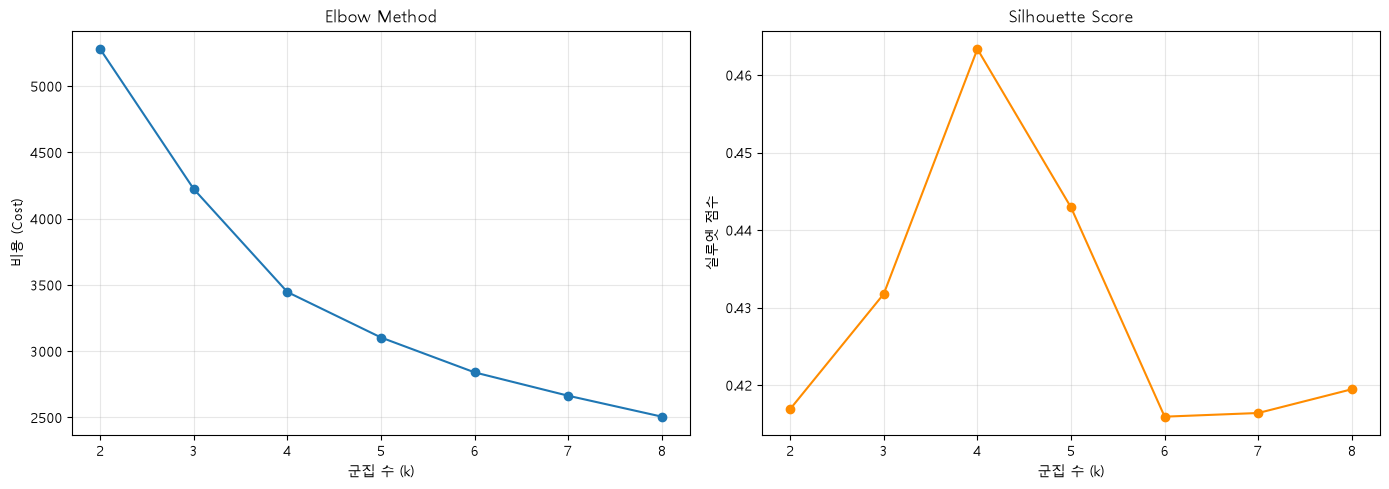

In [12]:
# Step 3-3. k 결정 - Elbow Method (k-prototypes), Silhouette Score (k-prototypes용 커스텀 거리 기반)
# Cost(비용) 값이 k가 증가함에 따라 급격히 줄다가 완만해지는 지점(elbow)을 찾음
# k-prototypes는 수치형(유클리드) + 범주형(매칭 거리)을 gamma로 합친 거리를 쓰기 때문에
# sklearn의 기본 silhouette_score를 바로 못 씀 -> 같은 방식으로 거리행렬을 직접 만들어서 precomputed로 계산

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from kmodes.kprototypes import KPrototypes
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

numeric_cols = ["Income", "Age", "Children"]
categorical_cols = ["Education", "Marital_Status"]
cluster_cols = numeric_cols + categorical_cols

df_cluster = df[cluster_cols].copy()

scaler = StandardScaler()
df_num_scaled = scaler.fit_transform(df_cluster[numeric_cols])
df_cat = df_cluster[categorical_cols].astype(str).values

categorical_idx = [3, 4]  # df_cluster_scaled 기준 Education, Marital_Status 위치
X_cluster = pd.concat(
    [pd.DataFrame(df_num_scaled, columns=numeric_cols), df_cluster[categorical_cols].astype(str)],
    axis=1
).values

# --- 혼합 거리행렬 계산 함수 ---
# 수치형: 유클리드 거리(제곱합) / 범주형: 다르면 1, 같으면 0 (매칭 거리) / gamma로 두 파트 결합
def mixed_distance_matrix(X_num, X_cat, gamma):
    num_dist = squareform(pdist(X_num, metric='euclidean')) ** 2
    n = X_cat.shape[0]
    cat_dist = np.zeros((n, n))
    for col in range(X_cat.shape[1]):
        col_vals = X_cat[:, col]
        mismatch = (col_vals[:, None] != col_vals[None, :]).astype(float)
        cat_dist += mismatch
    return num_dist + gamma * cat_dist

k_range = range(2, 9)
costs = []
sil_scores = []

for k in k_range:
    kproto = KPrototypes(n_clusters=k, init='Cao', n_init=5, random_state=42, verbose=0)
    labels = kproto.fit_predict(X_cluster, categorical=categorical_idx)
    costs.append(kproto.cost_)

    dist_matrix = mixed_distance_matrix(df_num_scaled, df_cat, gamma=kproto.gamma)
    sil = silhouette_score(dist_matrix, labels, metric='precomputed')
    sil_scores.append(sil)

    print(f"k={k}, cost={kproto.cost_:.2f}, silhouette={sil:.4f}")

# --- 시각화: Elbow + Silhouette 나란히 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), costs, marker='o')
axes[0].set_xlabel("군집 수 (k)")
axes[0].set_ylabel("비용 (Cost)")
axes[0].set_title("Elbow Method")
axes[0].set_xticks(list(k_range))
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), sil_scores, marker='o', color='darkorange')
axes[1].set_xlabel("군집 수 (k)")
axes[1].set_ylabel("실루엣 점수")
axes[1].set_title("Silhouette Score")
axes[1].set_xticks(list(k_range))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== 세그먼트별 고객 수 ===
세그먼트
0    422
1    617
2    423
3    574
Name: count, dtype: int64

=== PCA 설명 분산 비율 ===
PC1: 31.3%
PC2: 25.0%
누적: 56.3%

=== PCA 로딩 (변수 기여도) ===
                              PC1       PC2
Income                   0.735516  0.106526
Children                -0.622944  0.492896
Age                      0.263363  0.856623
Education_PhD            0.027503  0.065418
Education_Basic         -0.020183 -0.021819
Marital_Status_Widow     0.013478  0.024714
Marital_Status_Married  -0.011849 -0.011908
Education_Master        -0.008585 -0.006010
Marital_Status_Single   -0.004728 -0.061297
Marital_Status_Divorced  0.003648  0.026660
Education_Graduation     0.001266 -0.037589
Marital_Status_Together -0.000550  0.021831


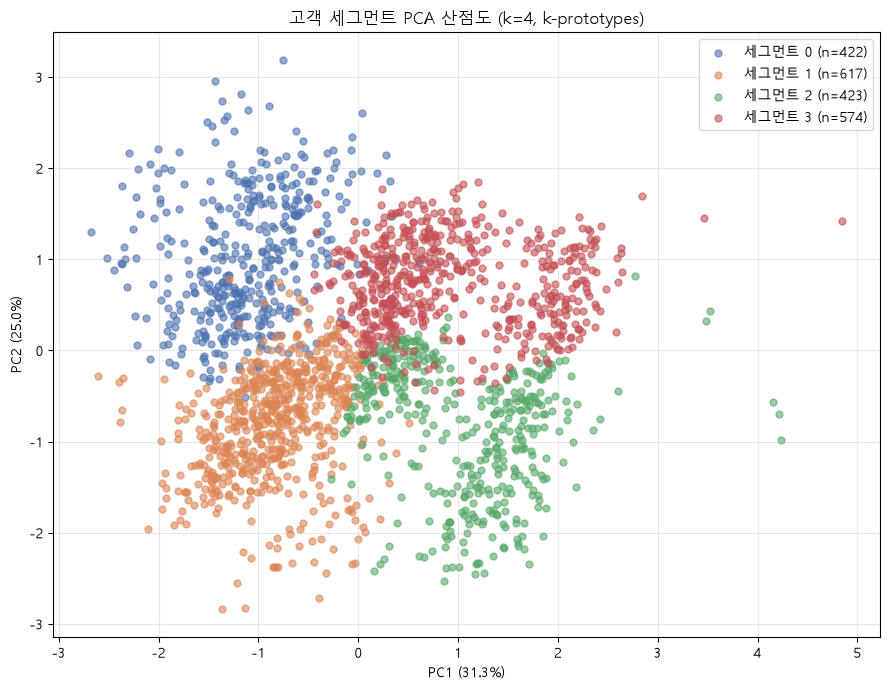


=== 세그먼트별 평균/최빈값 프로파일 ===
            Income        Age  Children   Education Marital_Status
세그먼트                                                              
0     45255.405213  48.895735  2.113744  Graduation        Married
1     31948.560778  36.380875  0.883306  Graduation        Married
2     74021.851064  37.234043  0.387707  Graduation        Married
3     62420.874564  57.573171  0.590592  Graduation        Married


In [13]:
# Step 3-4. 최종 클러스터링(k=4) + PCA 시각화

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

numeric_cols = ["Income", "Age", "Children"]
categorical_cols = ["Education", "Marital_Status"]
cluster_cols = numeric_cols + categorical_cols

df_cluster = df[cluster_cols].copy()

scaler = StandardScaler()
df_cluster_scaled = df_cluster.copy()
df_cluster_scaled[numeric_cols] = scaler.fit_transform(df_cluster[numeric_cols])
df_cluster_scaled[categorical_cols] = df_cluster_scaled[categorical_cols].astype(str)

X_cluster = df_cluster_scaled.values
categorical_idx = [df_cluster_scaled.columns.get_loc(c) for c in categorical_cols]

# --- k=4로 최종 클러스터링 ---
kproto_final = KPrototypes(n_clusters=4, init='Cao', n_init=10, random_state=42, verbose=0)
cluster_labels = kproto_final.fit_predict(X_cluster, categorical=categorical_idx)

df["세그먼트"] = cluster_labels
print("=== 세그먼트별 고객 수 ===")
print(df["세그먼트"].value_counts().sort_index())

# --- PCA는 수치형만 다루기 때문에, 시각화 목적으로 범주형을 원-핫 인코딩하여 별도 처리 ---
# (주의: 이 원-핫 인코딩은 "PCA 좌표 위에 클러스터를 뿌려보기 위한 시각화 전용"이며,
#  실제 클러스터링(k-prototypes)에 사용된 방식과는 무관함)
df_onehot = pd.get_dummies(df_cluster[categorical_cols], drop_first=False)
X_pca_input = pd.concat(
    [pd.DataFrame(df_cluster_scaled[numeric_cols].values, columns=numeric_cols), df_onehot],
    axis=1
)

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_pca_input)

print(f"\n=== PCA 설명 분산 비율 ===")
print(f"PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"누적: {pca.explained_variance_ratio_[:2].sum()*100:.1f}%")

# --- PCA 로딩(각 변수가 PC1/PC2에 얼마나 기여하는지) ---
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=X_pca_input.columns
)
print("\n=== PCA 로딩 (변수 기여도) ===")
print(loadings.sort_values("PC1", key=abs, ascending=False))

# --- 산점도 시각화 ---
plt.figure(figsize=(9, 7))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for seg in sorted(df["세그먼트"].unique()):
    mask = df["세그먼트"] == seg
    plt.scatter(pca_result[mask, 0], pca_result[mask, 1],
                label=f"세그먼트 {seg} (n={mask.sum()})",
                alpha=0.6, s=25, color=colors[seg])

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("고객 세그먼트 PCA 산점도 (k=4, k-prototypes)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 세그먼트별 특성 요약 (프로파일링) ---
print("\n=== 세그먼트별 평균/최빈값 프로파일 ===")
profile_numeric = df.groupby("세그먼트")[numeric_cols].mean()
profile_categorical = df.groupby("세그먼트")[categorical_cols].agg(lambda x: x.mode()[0])
profile = pd.concat([profile_numeric, profile_categorical], axis=1)
print(profile)

In [14]:
# 세그먼트별 Education / Marital_Status 비율 분포 확인
# (최빈값만 같았던 건지, 분포 자체가 실제로 다른지 확인)

import pandas as pd

pd.set_option('display.float_format', lambda x: f'{x:.1%}')

print("=== 세그먼트별 Education 비율 분포 ===")
edu_dist = df.groupby('세그먼트')['Education'].value_counts(normalize=True).unstack()
print(edu_dist)

print("\n=== 세그먼트별 Marital_Status 비율 분포 ===")
marital_dist = df.groupby('세그먼트')['Marital_Status'].value_counts(normalize=True).unstack()
print(marital_dist)

=== 세그먼트별 Education 비율 분포 ===
Education  Basic  Graduation  Master   PhD
세그먼트                                      
0           0.2%       48.1%   26.3% 25.4%
1           7.1%       49.3%   27.7% 15.9%
2            NaN       54.1%   23.2% 22.7%
3           0.7%       50.3%   24.6% 24.4%

=== 세그먼트별 Marital_Status 비율 분포 ===
Marital_Status  Divorced  Married  Single  Together  Widow
세그먼트                                                      
0                  12.1%    39.6%   18.5%     26.5%   3.3%
1                   7.6%    40.0%   26.4%     24.6%   1.3%
2                   9.7%    39.2%   23.6%     25.8%   1.7%
3                  12.7%    36.2%   19.0%     24.9%   7.1%


In [15]:
# gamma 값별 세그먼트별 Education / Marital_Status 전체 분포 표 출력

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes

pd.set_option('display.float_format', lambda x: f'{x:.1%}')

numeric_cols = ["Income", "Age", "Children"]
categorical_cols = ["Education", "Marital_Status"]
cluster_cols = numeric_cols + categorical_cols

df_cluster = df[cluster_cols].copy()
scaler = StandardScaler()
df_cluster_scaled = df_cluster.copy()
df_cluster_scaled[numeric_cols] = scaler.fit_transform(df_cluster[numeric_cols])
df_cluster_scaled[categorical_cols] = df_cluster_scaled[categorical_cols].astype(str)

X_cluster = df_cluster_scaled.values
categorical_idx = [df_cluster_scaled.columns.get_loc(c) for c in categorical_cols]

kproto_auto = KPrototypes(n_clusters=4, init='Cao', n_init=5, random_state=42, verbose=0)
kproto_auto.fit_predict(X_cluster, categorical=categorical_idx)
auto_gamma = kproto_auto.gamma

gamma_candidates = [auto_gamma * m for m in [1, 2, 4, 8]]

for g in gamma_candidates:
    kproto = KPrototypes(n_clusters=4, init='Cao', n_init=5, gamma=g, random_state=42, verbose=0)
    labels = kproto.fit_predict(X_cluster, categorical=categorical_idx)

    temp = df_cluster.copy()
    temp["세그먼트"] = labels

    print(f"========== gamma = {g:.4f} ==========")
    print("세그먼트별 인원:", temp["세그먼트"].value_counts().sort_index().to_dict())

    print("\nEducation 분포 (세그먼트별 비율):")
    print(temp.groupby("세그먼트")["Education"].value_counts(normalize=True).unstack().fillna(0))

    print("\nMarital_Status 분포 (세그먼트별 비율):")
    print(temp.groupby("세그먼트")["Marital_Status"].value_counts(normalize=True).unstack().fillna(0))
    print()

========== gamma = 0.5000 ==========
세그먼트별 인원: {0: 422, 1: 617, 2: 423, 3: 574}

Education 분포 (세그먼트별 비율):
Education  Basic  Graduation  Master   PhD
세그먼트                                      
0           0.2%       48.1%   26.3% 25.4%
1           7.1%       49.3%   27.7% 15.9%
2           0.0%       54.1%   23.2% 22.7%
3           0.7%       50.3%   24.6% 24.4%

Marital_Status 분포 (세그먼트별 비율):
Marital_Status  Divorced  Married  Single  Together  Widow
세그먼트                                                      
0                  12.1%    39.6%   18.5%     26.5%   3.3%
1                   7.6%    40.0%   26.4%     24.6%   1.3%
2                   9.7%    39.2%   23.6%     25.8%   1.7%
3                  12.7%    36.2%   19.0%     24.9%   7.1%

========== gamma = 1.0000 ==========
세그먼트별 인원: {0: 629, 1: 422, 2: 604, 3: 381}

Education 분포 (세그먼트별 비율):
Education  Basic  Graduation  Master   PhD
세그먼트                                      
0           7.0%       48.8%   28.3% 15.9%
1           0.2

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes


# 클러스터링에 사용할 변수 준비
numeric_cols = ["Income", "Age", "Children"]
categorical_cols = ["Education", "Marital_Status"]
cluster_cols = numeric_cols + categorical_cols
df_cluster = df[cluster_cols].copy()

# 수치형만 스케일링
scaler = StandardScaler()
df_cluster_scaled = df_cluster.copy()
df_cluster_scaled[numeric_cols] = scaler.fit_transform(df_cluster[numeric_cols])

# 범주형은 문자열로 유지 (K-Prototypes 요구사항)
df_cluster_scaled[categorical_cols] = df_cluster_scaled[categorical_cols].astype(str)
X_cluster = df_cluster_scaled.values
categorical_idx = [df_cluster_scaled.columns.get_loc(c) for c in categorical_cols]

# K-Prototypes 클러스터링 (K=4, gamma=0.5)
kproto = KPrototypes(n_clusters=4, init='Cao', gamma=0.5, random_state=777, n_init=10, verbose=0)
df['Cluster'] = kproto.fit_predict(X_cluster, categorical=categorical_idx)

# 세그먼트 이름 및 우선순위(Response율 기준) 매핑
segment_info = {
    2: ('VIP_Core_Customers', 1),        # Response 24.35% - 1순위
    0: ('Senior_Stable_Customers', 2),   # Response 15.68% - 2순위
    3: ('Low_Income_Young_Adults', 3),   # Response 11.99% - 3순위
    1: ('Middle_Aged_MultiChild', 4),    # Response 10.90% - 4순위
}

df['Segment_Name'] = df['Cluster'].map(lambda x: segment_info[x][0])
df['Segment_Priority'] = df['Cluster'].map(lambda x: segment_info[x][1])

# 확인
summary = df.groupby(['Segment_Priority', 'Segment_Name']).agg(
    count=('ID', 'count'),
    Response_rate=('Response', 'mean')
).round(4)
print(summary)

# CSV로 저장
df.to_csv('marketing_segmented.csv', index=False)
print('저장 완료')

                                          count  Response_rate
Segment_Priority Segment_Name                                 
1                VIP_Core_Customers         423          24.3%
2                Senior_Stable_Customers    574          15.7%
3                Low_Income_Young_Adults    617          12.0%
4                Middle_Aged_MultiChild     422          10.9%
저장 완료


In [18]:
# 포맷 옵션 초기화 (이전에 설정된 퍼센트 포맷이 남아있어서 오즈비가 잘못 표시된 문제 해결)
import pandas as pd
pd.reset_option('display.float_format')

# Step 4-1. H3 검증 (1) — 세그먼트별 AnyAccepted -> Response 오즈비 계산
# (사전 세그먼트가 지정된 파일 사용)

import pandas as pd
import numpy as np
import statsmodels.api as sm
segmented = pd.read_csv('marketing_segmented.csv')

# --- 세그먼트별로 각각 로지스틱 회귀 (AnyAccepted -> Response) ---

results = []
for seg in sorted(segmented["Cluster"].unique()):
    sub = segmented[segmented["Cluster"] == seg]
    seg_name = sub["Segment_Name"].iloc[0]

    X = sm.add_constant(sub[["AnyAccepted"]])
    y = sub["Response"]

    model = sm.Logit(y, X).fit(disp=0)
    or_val = np.exp(model.params["AnyAccepted"])
    ci = np.exp(model.conf_int().loc["AnyAccepted"])
    p_val = model.pvalues["AnyAccepted"]

    base_rate = sub.loc[sub["AnyAccepted"] == 0, "Response"].mean()
    treat_rate = sub.loc[sub["AnyAccepted"] == 1, "Response"].mean()

    results.append({
        "세그먼트": seg_name,
        "인원수": len(sub),
        "AnyAccepted=0 반응률": f"{base_rate*100:.1f}%",
        "AnyAccepted=1 반응률": f"{treat_rate*100:.1f}%",
        "오즈비": round(or_val, 3),
        "95% CI 하한": round(ci[0], 3),
        "95% CI 상한": round(ci[1], 3),
        "p-value": f"{p_val:.4f}"
    })

result_df = pd.DataFrame(results).sort_values("오즈비", ascending=False)
print("=== 세그먼트별 AnyAccepted -> Response 오즈비 ===")
print(result_df.to_string(index=False))

=== 세그먼트별 AnyAccepted -> Response 오즈비 ===
                   세그먼트  인원수 AnyAccepted=0 반응률 AnyAccepted=1 반응률   오즈비  95% CI 하한  95% CI 상한 p-value
Low_Income_Young_Adults  617              8.1%             45.3% 9.354      5.243     16.688  0.0000
     VIP_Core_Customers  423              9.9%             47.8% 8.321      4.999     13.850  0.0000
Senior_Stable_Customers  574              8.3%             36.2% 6.270      3.885     10.119  0.0000
 Middle_Aged_MultiChild  422              8.5%             30.4% 4.703      2.278      9.711  0.0000


In [19]:
# Step 4-2 H3 검증 (2) — 교호작용항(Interaction) 모델
# AnyAccepted x 세그먼트 교호작용이 통계적으로 유의한지 검정
# (세그먼트별 오즈비 차이가 우연이 아니라 진짜 패턴인지 확인)

import pandas as pd
import numpy as np
import statsmodels.api as sm

# 기준 세그먼트(reference)를 정하고 나머지는 더미 변수로
# VIP_Core_Customers를 기준으로 설정 (반응률이 가장 높아 비교 기준으로 직관적)
segmented["Segment_Name"] = pd.Categorical(
    segmented["Segment_Name"],
    categories=["high_Income_Young_Adults", "Senior_Stable_Customers",
                "Low_Income_Young_Adults", "Middle_Aged_MultiChild"]
)

seg_dummies = pd.get_dummies(segmented["Segment_Name"], prefix="Seg", drop_first=True).astype(int)

# 교호작용항 생성: AnyAccepted x 각 세그먼트 더미
X = pd.concat([segmented[["AnyAccepted"]], seg_dummies], axis=1)
for col in seg_dummies.columns:
    X[f"AnyAccepted_x_{col}"] = segmented["AnyAccepted"] * seg_dummies[col]

X = sm.add_constant(X)
y = segmented["Response"]

model_interaction = sm.Logit(y, X).fit(disp=0)
print(model_interaction.summary())

print("\n=== 교호작용항 오즈비 해석 ===")
print("(기준 세그먼트: high_Income_Young_Adults)")
print("각 계수는 'high_Income_Young_Adults 대비, 해당 세그먼트에서 AnyAccepted 효과가 얼마나 다른가'를 나타냄")
print("(로그오즈비 단위이므로, exp() 취하면 '효과 배율의 배율'이 됨)\n")

for col in seg_dummies.columns:
    interact_col = f"AnyAccepted_x_{col}"
    coef = model_interaction.params[interact_col]
    p_val = model_interaction.pvalues[interact_col]
    ratio_of_or = np.exp(coef)
    print(f"{col}: 교호작용 계수={coef:.3f}, p={p_val:.4f}, "
          f"high_Income_Young_Adults 대비 오즈비 배율={ratio_of_or:.3f} {'(유의함)' if p_val < 0.05 else '(유의하지 않음)'}")

# --- LR test: 교호작용항 전체가 모델 설명력에 유의한 기여를 하는지 ---
X_no_interact = sm.add_constant(pd.concat([segmented[["AnyAccepted"]], seg_dummies], axis=1))
model_no_interact = sm.Logit(y, X_no_interact).fit(disp=0)

lr_stat = 2 * (model_interaction.llf - model_no_interact.llf)
df_diff = model_interaction.df_model - model_no_interact.df_model
from scipy.stats import chi2
lr_p = chi2.sf(lr_stat, df_diff)

print(f"\n=== LR test (교호작용항 전체의 유의성) ===")
print(f"LR statistic: {lr_stat:.3f}, df={df_diff:.0f}, p-value={lr_p:.4f}")
print("-> p < 0.05면 '세그먼트에 따라 AnyAccepted 효과가 유의하게 다르다'는 근거")

                           Logit Regression Results                           
Dep. Variable:               Response   No. Observations:                 2036
Model:                          Logit   Df Residuals:                     2028
Method:                           MLE   Df Model:                            7
Date:                Tue, 25 Aug 2026   Pseudo R-squ.:                  0.1369
Time:                        14:27:07   Log-Likelihood:                -754.10
converged:                       True   LL-Null:                       -873.71
Covariance Type:            nonrobust   LLR p-value:                 5.438e-48
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
const                                        -2.2057      0.207    -10.674      0.000      -2.611      -1.801
AnyAccepted                           

C:\Users\ahnny\AppData\Local\Temp\ipykernel_21840\1411725692.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  segmented["Segment_Name"] = pd.Categorical(
